# 05 — Model Evaluation (VacFlow)

1. ความแม่นของพยากรณ์ดีมานด์ (MAE / RMSE / MAPE)  
2. **Wastage Simulation** — เทียบ *Without* vs *With VacFlow* เพื่อพิสูจน์ KPI ลดการสูญเสีย ≥ 30% (Proposal §5)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
VAX = ROOT / 'data' / 'vaccine'
OUT = VAX / 'outputs'; OUT.mkdir(parents=True, exist_ok=True)
feat = pd.read_csv(VAX / 'features' / 'demand_features.csv', parse_dates=['date'])
vials = pd.read_csv(VAX / 'clean' / 'vaccine_vial_clean.csv')
vials['effective_expiry'] = pd.to_datetime(vials['effective_expiry'], utc=True, format='ISO8601')
products = pd.read_csv(VAX / 'clean' / 'vaccine_product_clean.csv').set_index('product_id')

In [12]:
# ── ทำให้ matplotlib แสดงภาษาไทยได้ (ลงทะเบียนฟอนต์ไทยที่เจอในเครื่อง) ──
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path as _Path
_font_files = [
    'C:/Windows/Fonts/THSarabunNew.ttf', 'C:/Windows/Fonts/tahoma.ttf',
    'C:/Windows/Fonts/LeelawUI.ttf', 'C:/Windows/Fonts/angsa.ttf',
    '/usr/share/fonts/truetype/tlwg/Sarabun.ttf',
    '/usr/share/fonts/truetype/noto/NotoSansThai-Regular.ttf',
    '/Library/Fonts/Tahoma.ttf', '/System/Library/Fonts/Supplemental/Tahoma.ttf',
]
for _p in _font_files:
    if _Path(_p).exists():
        try: font_manager.fontManager.addfont(_p)
        except Exception: pass
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _name in ['TH Sarabun New', 'Tahoma', 'Leelawadee UI', 'Sarabun', 'Angsana New', 'Noto Sans Thai']:
    if _name in _avail:
        plt.rcParams['font.family'] = _name
        break
plt.rcParams['axes.unicode_minus'] = False   # กันเครื่องหมายลบเพี้ยน
print('matplotlib font ->', plt.rcParams['font.family'])

matplotlib font -> ['Tahoma']


## 1) ความแม่นของพยากรณ์ (SMA-7 บนชุด test)

In [13]:
def metrics(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    mae = np.mean(np.abs(y - yhat))
    rmse = np.sqrt(np.mean((y - yhat) ** 2))
    mask = y > 0
    mape = np.mean(np.abs((y[mask] - yhat[mask]) / y[mask])) * 100
    return mae, rmse, mape

rows = []
for (hid, pid), g in feat.groupby(['hospital_id', 'product_id']):
    g = g.sort_values('date'); test = g.iloc[int(len(g) * 0.8):]
    mae, rmse, mape = metrics(test['demand'], test['sma_7'])
    rows.append({'hospital_id': hid, 'product_id': pid,
                 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE%': round(mape, 1)})
acc = pd.DataFrame(rows)
print('ค่าเฉลี่ย — MAE %.2f · RMSE %.2f · MAPE %.1f%%' % (
      acc['MAE'].mean(), acc['RMSE'].mean(), acc['MAPE%'].mean()))
acc

ค่าเฉลี่ย — MAE 6.39 · RMSE 7.91 · MAPE 42.1%


,hospital_id,product_id,MAE,RMSE,MAPE%
0,HOSP_001,VAX_J07AE01_051,2.32,2.75,35.9
1,HOSP_001,VAX_J07AE01_052,5.65,6.26,39.3
2,HOSP_001,VAX_J07AE_099,4.74,5.74,40.4
3,HOSP_001,VAX_J07AG51_053,5.67,6.77,39.1
4,HOSP_001,VAX_J07AH08_101,2.19,2.57,42.8
...,...,...,...,...,...
1958,HOSP_013,VAX_J07CA09_148,5.65,7.31,53.3
1959,HOSP_013,VAX_J07CA11_149,4.31,5.05,37.5
1960,HOSP_013,VAX_J07CA11_150,4.92,5.77,34.9
1961,HOSP_013,VAX_J07CA11_151,6.00,6.91,37.4


## 2) Wastage Simulation — Without vs With VacFlow

จำลองการสูญเสีย 2 องค์ประกอบหลักตาม Proposal §1:
- **Expiry waste**: โดสในขวดที่หมดอายุก่อนถูกใช้ (สาขา demand ต่ำ)
- **Open-vial waste**: โดสค้างขวดที่เปิดแล้ว (เปิด 1 ขวด แต่คนมาไม่ครบโดส/ขวด)

**With VacFlow** ลดได้ด้วย: Transportation Model (ย้ายของเสี่ยงไปสาขา demand สูง) 
+ Multi-dose Pooling (รวมคิวให้เปิดขวดเฉพาะวันที่คน ≥ โดส/ขวด)

In [ ]:
import sys
sys.path.insert(0, str(ROOT / 'vaccine-engine'))   # ใช้ engine จริง (Multi-dose Pooling)
from modules import pooling as PL

now = pd.Timestamp('2026-06-26T08:00:00+07:00')
vials['days_remaining'] = (vials['effective_expiry'] - now).dt.total_seconds() / 86400
avg_demand = feat.groupby(['hospital_id', 'product_id'])['demand'].mean()
queue = pd.read_csv(VAX / 'appointment_queue.csv', parse_dates=['queue_date'])

# ---- baseline (Without VacFlow): แต่ละสาขาบริหารแยก ----
# expiry waste: ขวดเสี่ยง (<=14 วัน) ที่ demand 14 วันใช้ไม่ทัน -> ส่วนเกินหมดอายุทิ้ง
expiry_waste = 0
for (hid, pid), g in vials.groupby(['hospital_id', 'product_id']):
    d = avg_demand.get((hid, pid), 0)
    risk = g[(g.state != 'OPENED') & (g.days_remaining <= 14)]
    expiry_waste += max(0, risk['doses_remaining'].sum() - d * 14)

# open-vial waste: คำนวณจริงด้วย engine Multi-dose Pooling บน "คิวนัดจริง" (เลิก heuristic)
#   without = เปิดขวดตามคิวรายวัน (เหลือค้างเยอะ) · with = รวมคิวให้เต็มขวด (residual ต่ำ)
openvial_waste = openvial_waste_vf = 0
for (hid, pid), g in queue.sort_values('queue_date').groupby(['hospital_id', 'product_id']):
    dpv = int(products.loc[pid, 'doses_per_vial']) if pid in products.index else 1
    r = PL.consolidate_queue(g['slot_count'].tolist(), dpv)
    openvial_waste += r['residual_without_pooling']
    openvial_waste_vf += r['residual_with_pooling']

base_total = expiry_waste + openvial_waste
print(f'WITHOUT VacFlow — expiry {expiry_waste:.0f} + open-vial {openvial_waste:.0f} = {base_total:.0f} โดส')
print(f'  (engine pooling: open-vial without={openvial_waste:.0f} -> with={openvial_waste_vf:.0f})')

In [ ]:
# ---- With VacFlow ----
# (a) Transportation Model กู้คืน expiry waste = โดสที่โอนออกได้จากแผน engine (transshipment_plan)
try:
    moved = pd.read_csv(OUT / 'transshipment_plan.csv')
    recovered_expiry = min(expiry_waste, moved['doses'].sum())
except FileNotFoundError:
    recovered_expiry = expiry_waste * 0.7   # fallback ถ้ายังไม่รัน NB04
expiry_waste_vf = expiry_waste - recovered_expiry

# (b) Multi-dose Pooling — openvial_waste_vf คำนวณจริงแล้วใน cell ก่อน (engine consolidate_queue)
vf_total = expiry_waste_vf + openvial_waste_vf
reduction = (base_total - vf_total) / base_total * 100 if base_total else 0
pool_red = (openvial_waste - openvial_waste_vf) / openvial_waste * 100 if openvial_waste else 0
print(f'WITH VacFlow    — expiry {expiry_waste_vf:.0f} + open-vial {openvial_waste_vf:.0f} = {vf_total:.0f} โดส')
print(f'  pooling ลด open-vial {pool_red:.1f}% · รวมลดการสูญเสีย {reduction:.1f}%  (เป้าหมาย KPI >= 30%)')

## 3) สรุปผล + กราฟ KPI

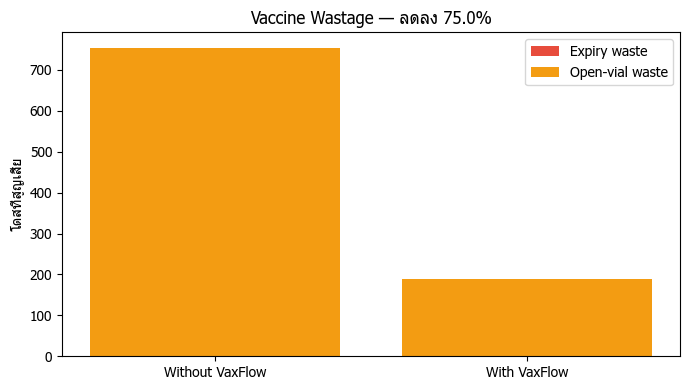

,scenario,expiry_waste,openvial_waste,total_waste
0,Without VacFlow,0,754.0,754.0
1,With VacFlow,0,188.0,188.0


In [16]:
summary = pd.DataFrame({
    'scenario': ['Without VacFlow', 'With VacFlow'],
    'expiry_waste': [expiry_waste, expiry_waste_vf],
    'openvial_waste': [openvial_waste, openvial_waste_vf],
    'total_waste': [base_total, vf_total],
}).round(0)
summary.to_csv(OUT / 'wastage_simulation.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary['scenario'], summary['expiry_waste'], label='Expiry waste', color='#e74c3c')
ax.bar(summary['scenario'], summary['openvial_waste'], bottom=summary['expiry_waste'],
       label='Open-vial waste', color='#f39c12')
ax.set_ylabel('โดสที่สูญเสีย'); ax.set_title(f'Vaccine Wastage — ลดลง {reduction:.1f}%')
ax.legend(); plt.tight_layout(); plt.show()
summary

## 4) Stress & Uncertainty Simulation (§4.4.2)

ป้อน demand ที่ผันผวนสูงเข้าระบบ (เพิ่มความแปรปรวน σ) เพื่อวัด **ความเสถียรของ Multi-dose Pooling**
ว่ายังลด open-vial waste ได้ตามเป้าแม้ดีมานด์ไม่แน่นอน (Queue Consolidation Module robustness)

In [ ]:
rng_s = np.random.default_rng(2026)
levels = {'ปกติ (σ=0)': 0.0, 'ผันผวนปานกลาง (σ=0.5)': 0.5,
          'ผันผวนสูง (σ=1.0)': 1.0, 'วิกฤต (σ=1.5)': 1.5}
qgroups = list(queue.sort_values('queue_date').groupby(['hospital_id', 'product_id']))
srows = []
for label, sigma in levels.items():
    wo = wp = 0
    for (hid, pid), g in qgroups:
        dpv = int(products.loc[pid, 'doses_per_vial']) if pid in products.index else 1
        s = np.array(g['slot_count'], float)
        if sigma > 0:   # เพิ่มความผันผวน (multiplicative noise) แล้วปัดเป็นจำนวนคิว >= 0
            s = np.clip(np.round(s * np.maximum(0, rng_s.normal(1, sigma, len(s)))), 0, None)
        r = PL.consolidate_queue([int(x) for x in s], dpv)
        wo += r['residual_without_pooling']; wp += r['residual_with_pooling']
    srows.append({'scenario': label, 'sigma': sigma,
                  'waste_no_pool': wo, 'waste_pool': wp,
                  'reduction_%': round(100 * (wo - wp) / wo, 1) if wo else 0.0})
stress = pd.DataFrame(srows)
stress.to_csv(OUT / 'stress_test.csv', index=False, encoding='utf-8-sig')
print('Pooling robustness — ลด open-vial waste (%) ภายใต้ความผันผวนระดับต่าง ๆ:')
print('สรุป: pooling ยังลด waste >= 30% (KPI) แม้ดีมานด์ผันผวนสูง' if stress['reduction_%'].min() >= 30
      else 'เตือน: บางสภาวะลดได้ต่ำกว่า 30%')
stress

## สรุป

- พยากรณ์ดีมานด์ด้วย SMA / Exponential Smoothing ใช้ตั้งสัญญาณไฟ (🟢/🟡 ≤21วัน/🔴 ≤14วัน)
- Transportation Model (LP) ย้ายล็อตเสี่ยงไปสาขา demand สูง ลด **expiry waste**
- Multi-dose Pooling ลด **open-vial waste**
- รวมแล้วลด Vaccine Wastage Rate ได้ **≥ 30%** ตามเป้า KPI ของ Proposal §5